# [9660] Exercise # 6 - Decision Tree - Solution
Data file:
* sklearn : wine

## Exercise # 6 Requirements
* Load data into dataframe
* Examine data
* Prepare data for model training and testing
  * Separate independent and dependent variables
  * Split train and test sets
* Train decision tree classifier model with default hyperparameters
  * Predict using the test set
  * Calculate and display model accuracy
  * Display feature importances
  * Visualize decision tree
* Train decision tree classifier model with at least 1 different hyperparameter
  * Predict using the test set
  * Calculate and display model accuracy
  * Display feature importances
  * Visualize decision tree

In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 10/27/24 14:15:00


### Mount your Google Drive
Execute the cell below and carefully follow the instructions

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# The location below is your Google Drive
#%cd "/content/gdrive/My Drive/CIS9660"

# The location below is the professor's Google Drive folder for this class
%cd "/content/gdrive/My Drive/BaruchCollege/Fall 2024/CIS9660_URA_DataMiningForBusinessAnalytics/ColabNotebooks"

/content/gdrive/My Drive/BaruchCollege/Fall 2024/CIS9660_URA_DataMiningForBusinessAnalytics/ColabNotebooks


### Import libraries

In [4]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
import cv2

### Load data

In [5]:
# Use load_wine()
wine = load_wine()

In [6]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [7]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['label'] = wine.target

### Examine data

In [8]:
df.shape

(178, 14)

In [9]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Check for missing values

In [10]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


### Separate independent and dependent variables

In [11]:
# Setup independent and dependent variables
X = df.drop(['label'], axis = 1)
y = df['label']

### Set global variable

In [12]:
global RANDOM_STATE
RANDOM_STATE=42

### Split data into training and test sets

In [13]:
# Split training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=RANDOM_STATE)

### Train model

In [14]:
# Fit a DecisionTreeClassifier model
model_1 = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_1.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [15]:
model_1.fit(X_train, y_train)
model_1.get_depth()

4

### Evaluate model

In [16]:
# Predict using the test set
y_pred = model_1.predict(X_test)

In [17]:
# Print model accuracy score
accuracy_score_1 = accuracy_score(y_test, y_pred)
print(f"Accuracy = {round((accuracy_score_1 * 100), 4)}%")

Accuracy = 94.4444%


In [18]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [19]:
# Display feature importances
model_1.feature_importances_

array([0.        , 0.01873775, 0.02016329, 0.02086548, 0.        ,
       0.        , 0.40807303, 0.        , 0.        , 0.40018907,
       0.        , 0.02098628, 0.11098512])

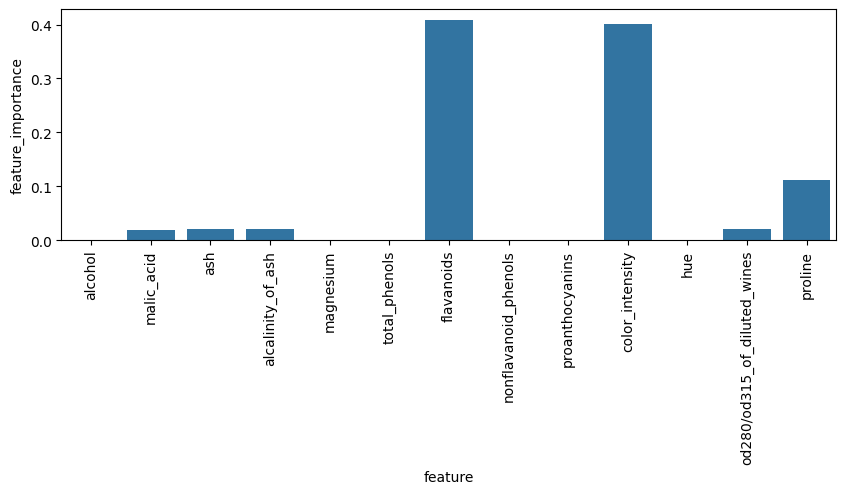

In [20]:
# Create new dataframe to display feature importances
df2 = pd.DataFrame(zip(wine.feature_names, model_1.feature_importances_),
                   columns=['feature', 'feature_importance'])

fig = plt.figure(figsize = (10, 3))
sns.barplot(data=df2, x='feature', y='feature_importance')
plt.xticks(rotation=90)
plt.show()

### Visualize model output

In [21]:
# Visualize decision tree. Create dot file.
export_graphviz(
    model_1,
    out_file = 'images/Ex7_DT_1.dot',
    feature_names = wine.feature_names,
    class_names = wine.target_names,
    filled = True,
    rounded = True
)

In [22]:
# Linux command to draw a directed graph from a representation of decision tree (dot file).
! dot -Tpng images/Ex7_DT_1.dot -o images/Ex7_DT_1.png

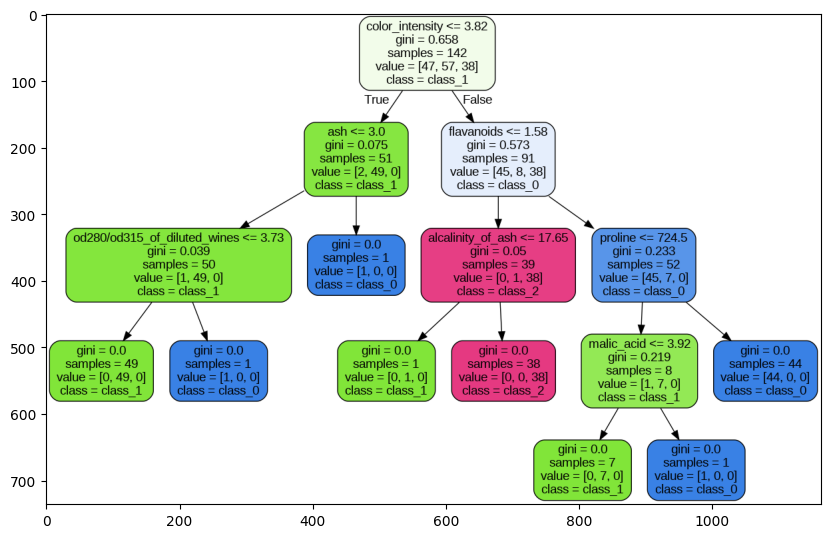

In [23]:
# Display directed graph
img = cv2.imread('images/Ex7_DT_1.png')
plt.figure(figsize = (10, 10))
plt.imshow(img)
plt.show()

### Train model with different hyperparameters

In [24]:
# Fit a DecisionTreeClassifier model with a different max_depth value
model_2 = DecisionTreeClassifier(criterion='log_loss', splitter='random', max_features='sqrt', random_state=RANDOM_STATE)
model_2.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'log_loss',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'random'}

In [25]:
model_2.fit(X_train, y_train)
model_2.get_depth()

10

### Evaluate model

In [26]:
# Predict using the test set
y_pred = model_2.predict(X_test)

In [27]:
# Print model accuracy score
accuracy_score_1 = accuracy_score(y_test, y_pred)
print(f"Accuracy = {round((accuracy_score_1 * 100), 4)}%")

Accuracy = 100.0%


In [28]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [29]:
# Display feature importances
model_2.feature_importances_

array([0.11667032, 0.05153776, 0.05602382, 0.03259124, 0.01116065,
       0.0440853 , 0.09290146, 0.        , 0.00201699, 0.06998367,
       0.12706433, 0.14493065, 0.25103382])

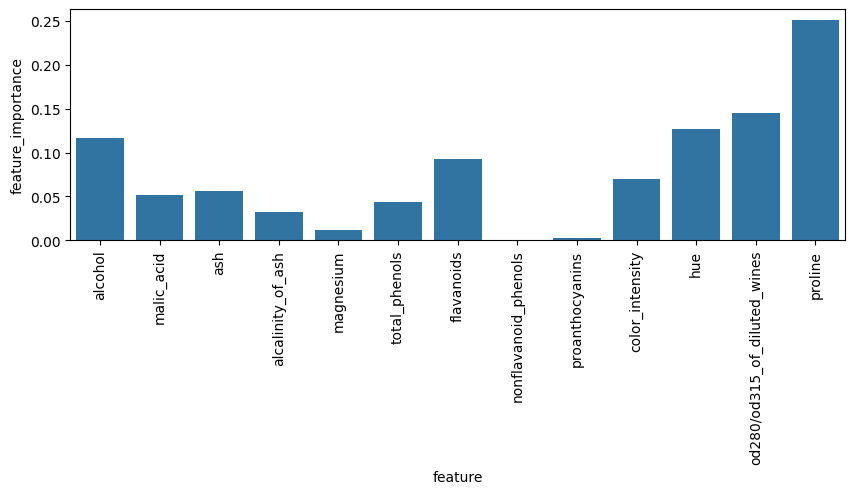

In [30]:
# Create new dataframe to display feature importances
df2 = pd.DataFrame(zip(wine.feature_names, model_2.feature_importances_),
                   columns=['feature', 'feature_importance'])

fig = plt.figure(figsize = (10, 3))
sns.barplot(data=df2, x='feature', y='feature_importance')
plt.xticks(rotation=90)
plt.show()

### Visualize model output

In [31]:
# Visualize decision tree. Create dot file.
export_graphviz(
            model_2,
            out_file = 'images/Ex7_DT_2.dot',
            feature_names = wine.feature_names,
            class_names = wine.target_names,
            filled = True,
            rounded = True)

In [32]:
# Linux command to draw a directed graph from a representation of decision tree (dot file).
! dot -Tpng images/Ex7_DT_2.dot -o images/Ex7_DT_2.png

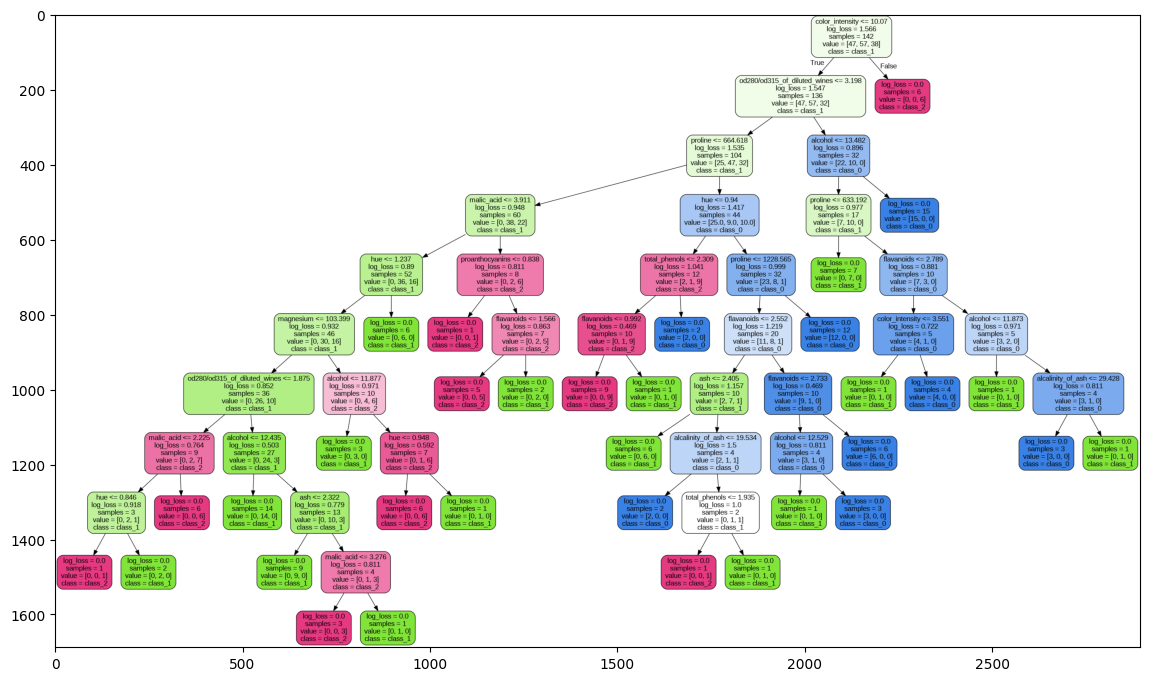

In [33]:
# Display directed graph
img = cv2.imread('images/Ex7_DT_2.png')
plt.figure(figsize = (14, 10))
plt.imshow(img)
plt.show()